# Olist E-Commerce Analysis - Customer RFM Segmentation

I want to understand what kinds of customers Olist has. The framework I'm using is RFM - Recency, Frequency, Monetary. You score each customer on how recently they bought, how many orders they've placed, and how much they've spent total. Combine the three and you get a rough picture of who your best customers are vs who's basically gone.

Before scoring anything, I wanted to check the repeat purchase rate first. My guess was that most people buy once and don't come back - Olist is a marketplace with lots of random categories, not exactly the kind of place you return to every week.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
BASE_DIR = os.path.abspath("..")
PROCESSED_PATH = os.path.join(BASE_DIR, "data", "processed")
CHARTS_PATH = os.path.join(BASE_DIR, "outputs", "charts")

# loading the cleaned master table
master = pd.read_csv(os.path.join(PROCESSED_PATH, "master_clean.csv"))
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])

print(f"loaded: {master.shape}")

loaded: (110197, 25)


## Step 1 - finding actual repeat customers

In [3]:
# important: customer_id in this dataset is NOT unique per person
# the same person gets a new customer_id every time they order
# customer_unique_id is the actual person identifier
# this is a gotcha in this dataset - took me a while to notice
# if I use customer_id I'll get 0% repeat rate which is wrong

repeat_check = master.groupby('customer_unique_id')['order_id'].nunique()
repeat_customers = (repeat_check > 1).sum()
total_customers = len(repeat_check)

print(f"total unique customers:           {total_customers:,}")
print(f"customers who bought more than once: {repeat_customers:,}")
print(f"repeat purchase rate:             {repeat_customers / total_customers * 100:.1f}%")

total unique customers:           93,358
customers who bought more than once: 2,801
repeat purchase rate:             3.0%


The repeat rate is really low - around 3%. That's a pretty common pattern in e-commerce marketplaces, especially in Brazil where Olist was still a growing platform during this period. Most customers came once and didn't come back. That makes the RFM segmentation even more interesting because the "Champions" are a tiny but very valuable group.

## Step 2 - computing RFM scores

In [4]:
# using the day after the last order as our reference point
reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = master.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

print(f"RFM table built - {len(rfm):,} customers")
print(rfm.describe())

RFM table built - 93,358 customers
            recency     frequency      monetary
count  93358.000000  93358.000000  93358.000000
mean     237.941773      1.033420    141.621480
std      152.591453      0.209097    215.694014
min        1.000000      1.000000      0.850000
25%      114.000000      1.000000     47.650000
50%      219.000000      1.000000     89.730000
75%      346.000000      1.000000    154.737500
max      714.000000     15.000000  13440.000000


In [5]:
# scoring each dimension from 1 to 5
# for recency: lower days = more recent = better, so we reverse it (5 = most recent)
# for frequency and monetary: higher is better, so 5 = highest
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# total rfm score = sum of the three (max 15, min 3)
rfm['rfm_score'] = (
    rfm['r_score'].astype(int) +
    rfm['f_score'].astype(int) +
    rfm['m_score'].astype(int)
)

print("RFM scores added")
print(rfm[['r_score', 'f_score', 'm_score', 'rfm_score']].head(10))

RFM scores added
  r_score f_score m_score  rfm_score
0       4       1       4          9
1       4       1       1          6
2       1       1       2          4
3       2       1       1          4
4       2       1       5          8
5       4       1       4          9
6       4       1       1          6
7       3       1       5          9
8       1       1       4          6
9       4       1       3          8


In [6]:
# assigning segment labels based on rfm_score
def assign_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm['rfm_score'].apply(assign_segment)

print("segment distribution:")
print(rfm['segment'].value_counts())

segment distribution:
segment
Potential Loyalists    38521
Loyal Customers        31260
At Risk                12434
Champions               7894
Lost                    3249
Name: count, dtype: int64


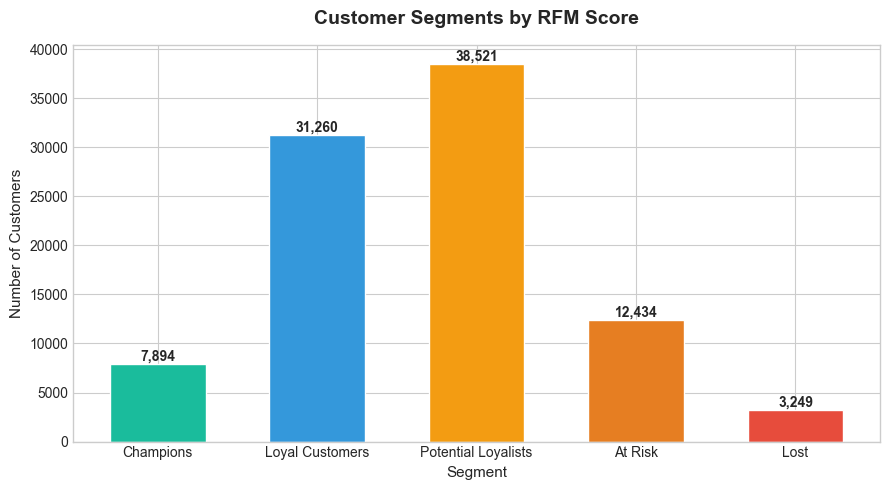

chart saved


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

segment_counts = rfm['segment'].value_counts()
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
colors_seg    = ['#1abc9c', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

# filtering to segments that actually exist
existing = [(s, c) for s, c in zip(segment_order, colors_seg) if s in segment_counts.index]
seg_labels = [s for s, c in existing]
seg_colors = [c for s, c in existing]
seg_values = [segment_counts[s] for s in seg_labels]

bars = ax.bar(seg_labels, seg_values, color=seg_colors, edgecolor='white', width=0.6)

ax.set_title('Customer Segments by RFM Score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Segment', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 50,
        f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, '04_rfm_segments.png'), dpi=150, bbox_inches='tight')
plt.show()
print("chart saved")

In [8]:
# summarizing each segment - average spend, recency, and size
seg_summary = rfm.groupby('segment').agg(
    avg_spend=('monetary', 'mean'),
    avg_recency=('recency', 'mean'),
    customer_count=('customer_unique_id', 'count')
).reset_index()

print("segment summary:")
print(seg_summary.sort_values('avg_spend', ascending=False).to_string(index=False))

segment summary:
            segment  avg_spend  avg_recency  customer_count
          Champions 298.460873    93.406765            7894
    Loyal Customers 188.556374   175.033237           31260
Potential Loyalists 109.136402   263.976870           38521
            At Risk  52.935682   355.062972           12434
               Lost  33.527270   437.479224            3249


In [9]:
# saving the rfm table
rfm.to_csv(os.path.join(PROCESSED_PATH, "rfm_segments.csv"), index=False)
print("RFM table saved")

RFM table saved


## what I found

3% repeat rate. I expected it to be low but not *that* low - only 2,801 out of 93k+ customers ever came back for a second order. Part of it is probably the nature of the marketplace (people come in for a specific thing and leave), part of it might be that Olist was still building its user base in this dataset period.

Champions (7,894 customers) spend almost $300 on average, which is about 3x what Loyal Customers spend. Small group but the kind of customers you really don't want to lose.

Potential Loyalists is the biggest segment at 38,521 people. Their recency scores are decent - they haven't completely disappeared. That feels like the most actionable group: bought once, not too far gone, a well-timed offer might bring them back.

At Risk (12,434) had decent scores earlier but recency is creeping up. If I were building a retention campaign I'd start here - they've shown they're willing to spend, they just need a reason to come back. The Lost segment (3,249) is harder to justify putting resources into.